In [5]:
#step 2
import numpy as np
import matplotlib.pyplot as plt

x_train= np.array([[-3.9852],[-7.2625],[2.8291],[-7.3045],[-6.1372],[1.6619],
                 [-4.9451],[2.6963],[6.6792],[-1.2995],[-2.6838],[-3.4715],
                 [-5.0195],[-2.9262],[-0.3013]]).reshape(-1,1)
y_train = np.array([
    [28.1908],
    [-86.2033],
    [-13.6625],
    [ 68.7593],
    [-223.631],
    [ -4.6456],
    [ 120.8628],
    [ 13.4804],
    [138.9255],
    [1.7485],
    [8.8414],
    [-35.1241],
    [90.9571],
    [-1.8887],
    [-0.0193]
]).reshape(-1,1)

x_test = np.array([[-5.9804],[-2.8337],[2.2868],[7.9915],[-3.504],[1.3156],
                 [5.9616],[4.6294],[-4.5106],[-2.454],[3.544],[-2.3373],
                 [-0.6291],[-4.0896],[-3.4774]]).reshape(-1,1)
y_test = np.array([
    [55.9095],
    [ -15.6288],
    [ -6.7248],
    [ 505.6809],
    [ -35.912],
    [ 2.5732],
    [ -208.5399],
    [ -94.5373],
    [ -55.7882],
    [10.9505],
    [21.6595],
    [2.9701],
    [-0.7869],
    [-44.7166],
    [-38.9733]
]).reshape(-1,1)

def sine_poly_features(X, K):
    # X = X.flatten()
    # N = X.shape[0]
    # Phi = np.zeros((N, K+1))
    # for k in range(K+1):
    #     Phi[:, k] = X**k
    # return Phi
    return np.hstack([np.sin(X**k) for k in range(K+1)])

def normalize_features(Phi):
    mu = np.mean(Phi, axis=0)
    sigma = np.std(Phi, axis=0)
    sigma[sigma == 0] = 1.0
    Phi_normalized = (Phi - mu) / sigma
    Phi_normalized[:,0] =1
    return Phi_normalized, mu, sigma

# Optimal polynomial degree
optimal_k = 4

# 1. Generate polynomial features
Phi = sine_poly_features(x_train, optimal_k)
Phi_test = sine_poly_features(x_test, optimal_k)

# 2. Normalize features
Phi, mu, sigma = normalize_features(Phi)
Phi_test = (Phi_test - mu) / sigma
Phi_test[:,0] =1

np.random.seed(42)
theta = np.random.uniform(-1,1,(optimal_k +1,1))
alpha = 0.0002
max_iter = 100000
decay_rate = 0.00001



Breaking at iteration 1 due to NaN or cost increase
Theta (Gradient Descent): [[-0.25386284]
 [ 0.89233546]
 [ 0.46662626]
 [ 0.21344094]
 [-0.69902441]]
Final Train RMSE: 84.5444429093877
Final Test RMSE: 145.5530048257098


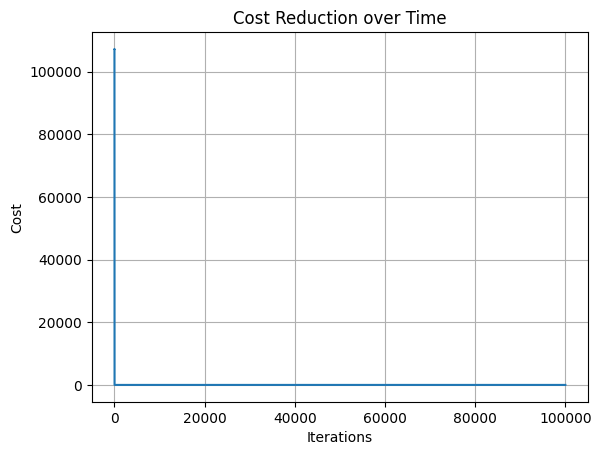

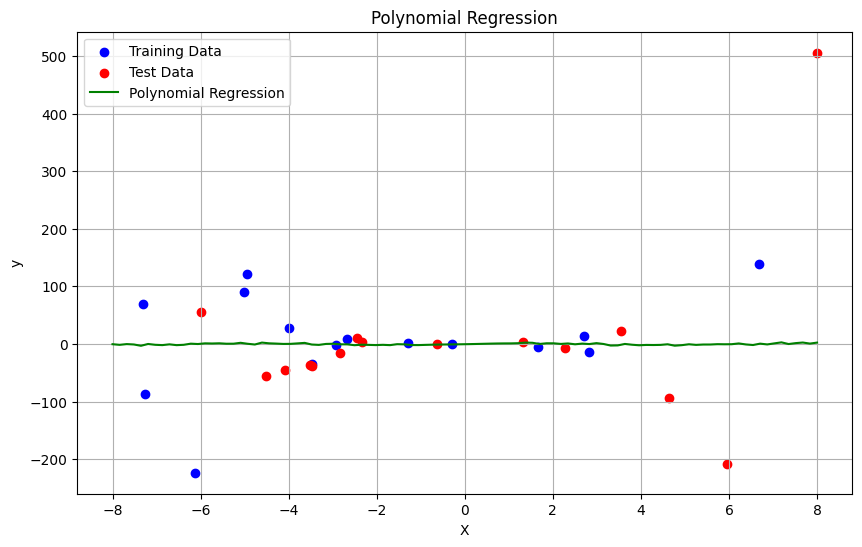

In [6]:
#step 3
def loss_function(Phi, y, theta):
    return np.sum((y - Phi.dot(theta)) ** 2)

def gradient_descent(X, y, theta, alpha, max_iter, decay_rate):
    n = len(y)
    cost_history = [0] * max_iter
    for i in range (max_iter):
      prediction = X.dot(theta)
      error =  y-prediction
      gradient = (1 / n) * X.T.dot(error)
      alpha_t = alpha/ (1+ decay_rate*i)
      theta -=alpha_t *gradient
      cost_history[i] = loss_function(X,y,theta)

      if np.isnan(cost_history[i]) or (i > 0 and cost_history[i] > cost_history[i - 1]):
            print(f"Breaking at iteration {i} due to NaN or cost increase")
            break
    return theta, cost_history

theta_gd, cost_history = gradient_descent(Phi, y_train, theta, alpha, max_iter,decay_rate)
print("Theta (Gradient Descent):", theta_gd)

y_train_pred = Phi @ theta_gd
y_test_pred = Phi_test @ theta_gd

def calculate_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

final_train_rmse = calculate_rmse(y_train, y_train_pred)
final_test_rmse = calculate_rmse(y_test, y_test_pred)

print("Final Train RMSE:", final_train_rmse)
print("Final Test RMSE:", final_test_rmse)

x_range = np.linspace (-8,8,100).reshape(-1,1)
x_range_poly = sine_poly_features(x_range, optimal_k)
x_range_poly = (x_range_poly - mu) / sigma
x_range_poly[:,0] =1
y_range_pred = x_range_poly @ theta_gd

# Plotting Cost History
plt.figure()
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Training Data', color='blue')
plt.scatter(x_test, y_test, label='Test Data', color='red')
plt.plot(x_range, y_range_pred, label='Polynomial Regression', color='green')
plt.legend()
plt.grid(True)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.show()

In [11]:
#step 4
def sine_poly_features(X, K):
    # X = X.flatten()
    # N = X.shape[0]
    # Phi = np.zeros((N, K+1))
    # for k in range(K+1):
    #     Phi[:, k] = X**k
    # return Phi
    return np.hstack([np.sin(X**k )for k in range(K+1)])

def normalize_features(Phi):
    mu = np.mean(Phi, axis=0)
    sigma = np.std(Phi, axis=0)
    sigma[sigma == 0] = 1.0
    Phi_normalized = (Phi - mu) / sigma
    Phi_normalized[:,0] =1
    return Phi_normalized, mu, sigma

# Optimal polynomial degree
optimal_k = 4

# 1. Generate polynomial features
Phi = sine_poly_features(x_train, optimal_k)
Phi_test = sine_poly_features(x_test, optimal_k)

# 2. Normalize features
Phi, mu, sigma = normalize_features(Phi)
Phi_test = (Phi_test - mu) / sigma
Phi_test[:,0] =1

np.random.seed(42)
theta = np.random.uniform(-1,1,(optimal_k+1,1))
alpha = 0.01
max_iter= 500000

def loss_function(Phi, y, theta):
    return np.sum((y - Phi.dot(theta)) ** 2)

def gradient_descent(X, y, theta, alpha, max_iter, decay_rate):
    n = len(y)
    cost_history = [0] * max_iter
    for i in range (max_iter):
      prediction = X.dot(theta)
      error =  y-prediction
      gradient = (1 / n) * X.T.dot(error)
      alpha_t = alpha/ (1+ decay_rate*i)
      theta -=alpha_t *gradient
      cost_history[i] = loss_function(X,y,theta)

      if np.isnan(cost_history[i]) or (i > 0 and cost_history[i] > cost_history[i - 1]):
            print(f"Breaking at iteration {i} due to NaN or cost increase")
            break
    return theta, cost_history

theta_gd, cost_history = gradient_descent(Phi, y_train, theta, alpha, max_iter,decay_rate)
# print("Theta (Gradient Descent):", theta_gd)

y_train_pred = Phi @ theta_gd
y_test_pred = Phi_test @ theta_gd

def calculate_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

final_train = calculate_rmse(y_train, y_train_pred)
final_test = calculate_rmse(y_test, y_test_pred)

print("Final Train RMSE:", final_train)
print("Final Test RMSE:", final_test)

Breaking at iteration 1 due to NaN or cost increase
Final Train RMSE: 85.25616818836858
Final Test RMSE: 145.36841911596434


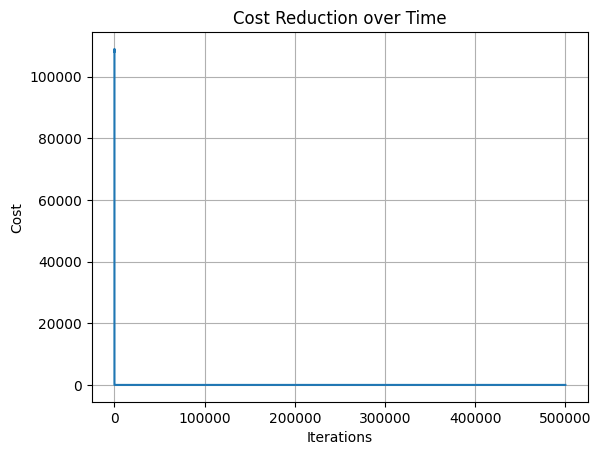

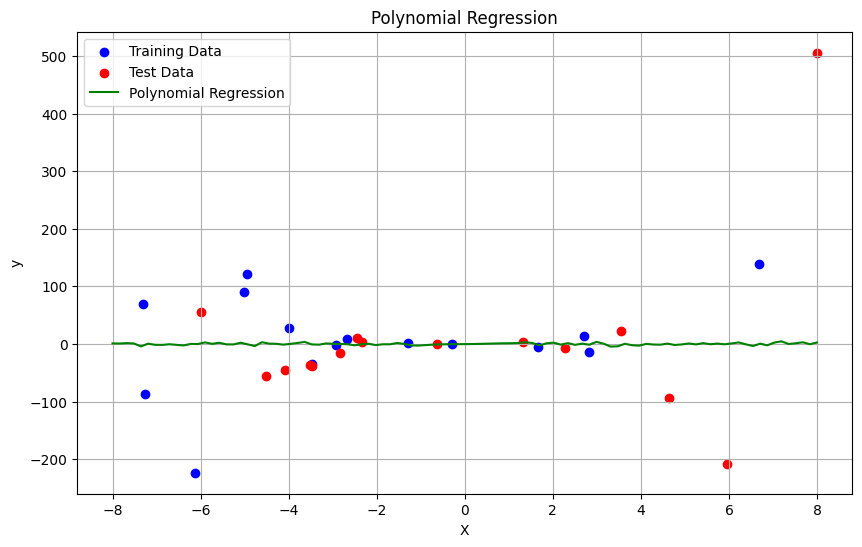

In [10]:

x_range = np.linspace (-8,8,100).reshape(-1,1)
x_range_poly = sine_poly_features(x_range, optimal_k)
x_range_poly = (x_range_poly - mu) / sigma
x_range_poly[:,0] =1
y_range_pred = x_range_poly @ theta_gd

# Plotting Cost History
plt.figure()
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction over Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Training Data', color='blue')
plt.scatter(x_test, y_test, label='Test Data', color='red')
plt.plot(x_range, y_range_pred, label='Polynomial Regression', color='green')
plt.legend()
plt.grid(True)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.show()